# Step 3 — MLP NARX, training & grid search over $(n_a, n_b)$

**5SC28 — Unbalanced Disc, ANN identification (no $\omega$)**

We train a small feedforward MLP $f_\varphi$ that maps $\varphi_k \to (\sin\theta_k, \cos\theta_k)$ for every combination of $(n_a, n_b) \in \{2,4,6,8\}^2$.

Selection criterion: **best validation RMSE on $\theta$** (angle reconstructed via `atan2`), with the standard angular-difference wrap fix.

Artifacts produced:
- `artifacts/step3_grid_results.csv` — full results table.
- `artifacts/best_narx.pt` — weights of the winning model, plus its $(n_a, n_b)$ and architecture metadata.

In [ ]:
import time, json, math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

WORK_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment"
)
ARTIFACTS = WORK_DIR / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0)
print('device:', device)

device: mps


## 3.1 — Load processed signals from Step 2

In [2]:
P = np.load(ARTIFACTS / 'step2_processed.npz')
u_tr_n, u_va_n = P['u_tr_n'], P['u_va_n']
sin_tr, cos_tr = P['sin_tr'], P['cos_tr']
sin_va, cos_va = P['sin_va'], P['cos_va']
th_tr, th_va   = P['th_tr'],  P['th_va']
Ts             = float(P['Ts'])
print(f'Train samples: {len(u_tr_n)}   Val samples: {len(u_va_n)}   Ts={Ts}s')

Train samples: 28000   Val samples: 7000   Ts=0.025s


## 3.2 — Regressor builder (same as Step 2, kept here for self-containment)

In [3]:
def create_IO_data_sincos(u_n, sin_th, cos_th, na, nb):
    n0 = max(na, nb)
    N = len(u_n); M = N - n0
    idx_u  = np.arange(M)[:, None] + np.arange(n0 - nb, n0)
    idx_th = np.arange(M)[:, None] + np.arange(n0 - na, n0)
    Xu  = u_n[idx_u]
    Xs  = sin_th[idx_th]
    Xc  = cos_th[idx_th]
    Xsc = np.empty((M, 2 * na), dtype=Xu.dtype)
    Xsc[:, 0::2] = Xs; Xsc[:, 1::2] = Xc
    X = np.concatenate([Xu, Xsc], axis=1).astype(np.float32)
    Y = np.stack([sin_th[n0:], cos_th[n0:]], axis=1).astype(np.float32)
    # We also return the corresponding true theta for RMSE-on-theta evaluation.
    return X, Y

## 3.3 — Model definition
Two hidden layers, 64 units each, `tanh` activation; linear output of size 2.

In [4]:
class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

## 3.4 — Helpers: wrapped angular error and RMSE on $\theta$

In [5]:
def wrap_pi(x):
    """Wrap an angle (radians) into [-pi, pi)."""
    return (x + np.pi) % (2 * np.pi) - np.pi

def rmse_theta_from_sincos(sin_pred, cos_pred, sin_true, cos_true):
    """RMSE on theta given (sin,cos) predictions. Uses atan2 and wrap.
    All inputs are numpy arrays of shape (N,)."""
    th_pred = np.arctan2(sin_pred, cos_pred)
    th_true = np.arctan2(sin_true, cos_true)
    err = wrap_pi(th_pred - th_true)
    return float(np.sqrt(np.mean(err ** 2)))

## 3.5 — Train one configuration

In [6]:
def train_one(na, nb, max_epochs=200, patience=15, batch_size=256, lr=1e-3,
              weight_decay=1e-5, hidden=64, verbose=False):
    Xtr, Ytr = create_IO_data_sincos(u_tr_n, sin_tr, cos_tr, na, nb)
    Xva, Yva = create_IO_data_sincos(u_va_n, sin_va, cos_va, na, nb)
    in_dim = Xtr.shape[1]

    Xtr_t = torch.from_numpy(Xtr).to(device)
    Ytr_t = torch.from_numpy(Ytr).to(device)
    Xva_t = torch.from_numpy(Xva).to(device)
    Yva_t = torch.from_numpy(Yva).to(device)

    loader = DataLoader(TensorDataset(Xtr_t, Ytr_t),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model = NARX_MLP(in_dim, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                       factor=1/3, patience=5)
    loss_fn = nn.MSELoss()

    history = {'train': [], 'val': []}
    best_val = float('inf'); best_state = None; bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0; n = 0
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward(); opt.step()
            epoch_loss += loss.item() * xb.size(0); n += xb.size(0)
        train_loss = epoch_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva_t), Yva_t).item()
        sched.step(val_loss)
        history['train'].append(train_loss); history['val'].append(val_loss)

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(f'  early stop at epoch {epoch} (best val={best_val:.5e})')
                break

    # Load best weights for the final eval.
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        Yhat_va = model(Xva_t).cpu().numpy()
    rmse_th = rmse_theta_from_sincos(
        Yhat_va[:, 0], Yhat_va[:, 1], Yva[:, 0], Yva[:, 1])

    return {
        'na': na, 'nb': nb, 'in_dim': in_dim,
        'best_val_loss': best_val,
        'val_rmse_theta_rad': rmse_th,
        'val_rmse_theta_deg': rmse_th * 180 / math.pi,
        'epochs_trained': epoch,
        'history': history,
        'state_dict': best_state,
        'hidden': hidden,
    }

## 3.6 — Grid search over the 16 combinations

In [7]:
grid = [(na, nb) for na in (2, 4, 6, 8) for nb in (2, 4, 6, 8)]
results = []
t0 = time.time()
for (na, nb) in grid:
    t_cfg = time.time()
    res = train_one(na, nb, verbose=False)
    dt = time.time() - t_cfg
    print(f'(na={na}, nb={nb})  in={res["in_dim"]:>2}  '
          f'epochs={res["epochs_trained"]:>3}  '
          f'val_loss={res["best_val_loss"]:.4e}  '
          f'RMSE_theta={res["val_rmse_theta_rad"]:.4f} rad ({res["val_rmse_theta_deg"]:.2f}\u00b0)  '
          f'[{dt:.1f}s]')
    results.append(res)
print(f'\nTotal time: {time.time()-t0:.1f}s')

(na=2, nb=2)  in= 6  epochs=171  val_loss=3.8169e-05  RMSE_theta=0.0060 rad (0.35°)  [46.9s]
(na=2, nb=4)  in= 8  epochs=181  val_loss=4.4025e-05  RMSE_theta=0.0066 rad (0.38°)  [48.1s]
(na=2, nb=6)  in=10  epochs=140  val_loss=5.9371e-05  RMSE_theta=0.0078 rad (0.44°)  [36.8s]
(na=2, nb=8)  in=12  epochs=184  val_loss=4.9033e-05  RMSE_theta=0.0070 rad (0.40°)  [47.8s]
(na=4, nb=2)  in=10  epochs=179  val_loss=2.7510e-05  RMSE_theta=0.0053 rad (0.31°)  [46.9s]
(na=4, nb=4)  in=12  epochs=173  val_loss=2.9440e-05  RMSE_theta=0.0050 rad (0.29°)  [45.2s]
(na=4, nb=6)  in=14  epochs=191  val_loss=3.1339e-05  RMSE_theta=0.0050 rad (0.29°)  [49.9s]
(na=4, nb=8)  in=16  epochs=189  val_loss=3.3837e-05  RMSE_theta=0.0053 rad (0.31°)  [49.0s]
(na=6, nb=2)  in=14  epochs=200  val_loss=2.6815e-05  RMSE_theta=0.0054 rad (0.31°)  [53.3s]
(na=6, nb=4)  in=16  epochs=199  val_loss=3.1770e-05  RMSE_theta=0.0059 rad (0.34°)  [52.7s]
(na=6, nb=6)  in=18  epochs=168  val_loss=2.7207e-05  RMSE_theta=0.005

## 3.7 — Results table and heatmap

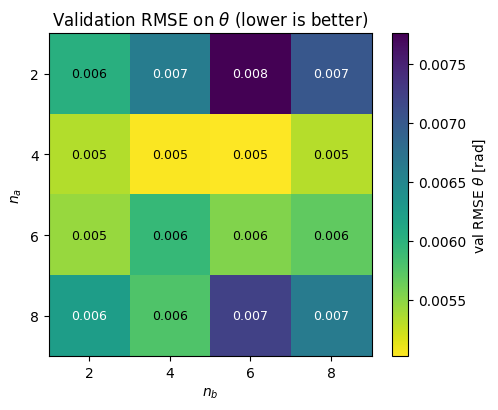

In [8]:
# Build a 4x4 matrix for visualization. Rows=na, cols=nb.
na_vals = (2, 4, 6, 8); nb_vals = (2, 4, 6, 8)
M = np.full((4, 4), np.nan)
for r in results:
    i = na_vals.index(r['na']); j = nb_vals.index(r['nb'])
    M[i, j] = r['val_rmse_theta_rad']

fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(M, cmap='viridis_r')
ax.set_xticks(range(4)); ax.set_xticklabels(nb_vals); ax.set_xlabel('$n_b$')
ax.set_yticks(range(4)); ax.set_yticklabels(na_vals); ax.set_ylabel('$n_a$')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{M[i,j]:.3f}', ha='center', va='center',
                color='white' if M[i,j] > M.mean() else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='val RMSE $\\theta$ [rad]')
ax.set_title('Validation RMSE on $\\theta$ (lower is better)')
plt.tight_layout(); plt.show()

In [9]:
# Sorted table.
rows = sorted(results, key=lambda r: r['val_rmse_theta_rad'])
print(f'{"na":>3} {"nb":>3} {"in_dim":>6} {"epochs":>6} {"val_loss":>12} {"RMSE_rad":>10} {"RMSE_deg":>9}')
for r in rows:
    print(f'{r["na"]:>3} {r["nb"]:>3} {r["in_dim"]:>6} {r["epochs_trained"]:>6} '
          f'{r["best_val_loss"]:>12.4e} {r["val_rmse_theta_rad"]:>10.4f} {r["val_rmse_theta_deg"]:>9.2f}')

# Save CSV.
import csv
with open(ARTIFACTS / 'step3_grid_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['na', 'nb', 'in_dim', 'epochs', 'best_val_loss',
                'val_rmse_theta_rad', 'val_rmse_theta_deg'])
    for r in rows:
        w.writerow([r['na'], r['nb'], r['in_dim'], r['epochs_trained'],
                    r['best_val_loss'], r['val_rmse_theta_rad'], r['val_rmse_theta_deg']])
print(f'\nSaved {ARTIFACTS / "step3_grid_results.csv"}')

 na  nb in_dim epochs     val_loss   RMSE_rad  RMSE_deg
  4   6     14    191   3.1339e-05     0.0050      0.29
  4   4     12    173   2.9440e-05     0.0050      0.29
  4   8     16    189   3.3837e-05     0.0053      0.31
  4   2     10    179   2.7510e-05     0.0053      0.31
  6   2     14    200   2.6815e-05     0.0054      0.31
  6   6     18    168   2.7207e-05     0.0055      0.32
  6   8     20    174   3.0194e-05     0.0057      0.33
  8   4     20    200   2.9581e-05     0.0058      0.33
  6   4     16    199   3.1770e-05     0.0059      0.34
  2   2      6    171   3.8169e-05     0.0060      0.35
  8   2     18    135   3.3731e-05     0.0062      0.36
  2   4      8    181   4.4025e-05     0.0066      0.38
  8   8     24    187   3.5620e-05     0.0066      0.38
  2   8     12    184   4.9033e-05     0.0070      0.40
  8   6     22    180   3.8876e-05     0.0072      0.41
  2   6     10    140   5.9371e-05     0.0078      0.44

Saved /Users/davidedeleonardis/Desktop/ml-contr

## 3.8 — Training curves of the best model

Winner: na=4, nb=6, in_dim=14, val RMSE = 0.0050 rad (0.29°)


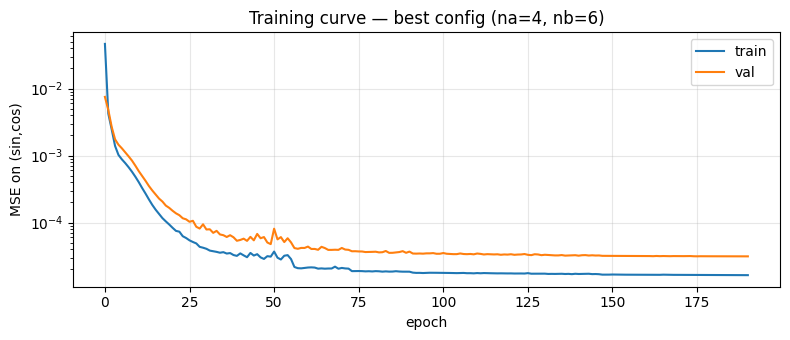

In [10]:
best = rows[0]
print(f'Winner: na={best["na"]}, nb={best["nb"]}, in_dim={best["in_dim"]}, '
      f'val RMSE = {best["val_rmse_theta_rad"]:.4f} rad ({best["val_rmse_theta_deg"]:.2f}\u00b0)')

h = best['history']
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogy(h['train'], label='train')
ax.semilogy(h['val'],   label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE on (sin,cos)'); ax.grid(alpha=0.3)
ax.legend(); ax.set_title(f'Training curve — best config (na={best["na"]}, nb={best["nb"]})')
plt.tight_layout(); plt.show()

## 3.9 — Save the winning model
Includes the metadata Step 4 needs to rebuild $\varphi_k$ and run prediction/simulation.

In [11]:
torch.save({
    'state_dict': best['state_dict'],
    'na': best['na'], 'nb': best['nb'],
    'in_dim': best['in_dim'],
    'hidden': best['hidden'],
    'U_SCALE': 3.0,
    'val_rmse_theta_rad': best['val_rmse_theta_rad'],
}, ARTIFACTS / 'best_narx.pt')
print('Saved', ARTIFACTS / 'best_narx.pt')

Saved /Users/davidedeleonardis/Desktop/ml-control-project/artifacts/best_narx.pt


---
**End of Step 3.**

Next: Step 4 — evaluate the winner on the *hidden* test sets in both **prediction** and **simulation** mode, and produce the submission files.